## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [1]:
# %pip install openmeteo-requests
# %pip install requests-cache retry-requests numpy pandas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import requests

# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230


url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

In [4]:
def get_weather(url):
    response = requests.get(url)

    if response.status_code == 200:  # Código 200 indica una respuesta exitosa.
        data = response.json()  # Analizar la respuesta JSON.
        return data
    else:
        print("Error en la solicitud: ", response.status_code)

In [5]:
url = 'https://api.open-meteo.com/v1/forecast?latitude=43.2540&longitude=-2.9230&hourly=temperature_2m'

In [6]:
weather = get_weather(url)
weather

{'latitude': 43.25,
 'longitude': -2.92,
 'generationtime_ms': 0.3069639205932617,
 'utc_offset_seconds': 0,
 'timezone': 'GMT',
 'timezone_abbreviation': 'GMT',
 'elevation': 14.0,
 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C'},
 'hourly': {'time': ['2026-03-24T00:00',
   '2026-03-24T01:00',
   '2026-03-24T02:00',
   '2026-03-24T03:00',
   '2026-03-24T04:00',
   '2026-03-24T05:00',
   '2026-03-24T06:00',
   '2026-03-24T07:00',
   '2026-03-24T08:00',
   '2026-03-24T09:00',
   '2026-03-24T10:00',
   '2026-03-24T11:00',
   '2026-03-24T12:00',
   '2026-03-24T13:00',
   '2026-03-24T14:00',
   '2026-03-24T15:00',
   '2026-03-24T16:00',
   '2026-03-24T17:00',
   '2026-03-24T18:00',
   '2026-03-24T19:00',
   '2026-03-24T20:00',
   '2026-03-24T21:00',
   '2026-03-24T22:00',
   '2026-03-24T23:00',
   '2026-03-25T00:00',
   '2026-03-25T01:00',
   '2026-03-25T02:00',
   '2026-03-25T03:00',
   '2026-03-25T04:00',
   '2026-03-25T05:00',
   '2026-03-25T06:00',
   '2026-03-25T07:00',
  

In [7]:
weather['hourly']['time']

['2026-03-24T00:00',
 '2026-03-24T01:00',
 '2026-03-24T02:00',
 '2026-03-24T03:00',
 '2026-03-24T04:00',
 '2026-03-24T05:00',
 '2026-03-24T06:00',
 '2026-03-24T07:00',
 '2026-03-24T08:00',
 '2026-03-24T09:00',
 '2026-03-24T10:00',
 '2026-03-24T11:00',
 '2026-03-24T12:00',
 '2026-03-24T13:00',
 '2026-03-24T14:00',
 '2026-03-24T15:00',
 '2026-03-24T16:00',
 '2026-03-24T17:00',
 '2026-03-24T18:00',
 '2026-03-24T19:00',
 '2026-03-24T20:00',
 '2026-03-24T21:00',
 '2026-03-24T22:00',
 '2026-03-24T23:00',
 '2026-03-25T00:00',
 '2026-03-25T01:00',
 '2026-03-25T02:00',
 '2026-03-25T03:00',
 '2026-03-25T04:00',
 '2026-03-25T05:00',
 '2026-03-25T06:00',
 '2026-03-25T07:00',
 '2026-03-25T08:00',
 '2026-03-25T09:00',
 '2026-03-25T10:00',
 '2026-03-25T11:00',
 '2026-03-25T12:00',
 '2026-03-25T13:00',
 '2026-03-25T14:00',
 '2026-03-25T15:00',
 '2026-03-25T16:00',
 '2026-03-25T17:00',
 '2026-03-25T18:00',
 '2026-03-25T19:00',
 '2026-03-25T20:00',
 '2026-03-25T21:00',
 '2026-03-25T22:00',
 '2026-03-25T

In [8]:
weather_dict = {
    # 'Dia':[],
    'Hora':[],
    'Temperatura':[]
}

# weather['hourly'] tiene estructura de diccionario, lo guardamos en el nuestro
weather_dict = weather['hourly']
weather_dict



{'time': ['2026-03-24T00:00',
  '2026-03-24T01:00',
  '2026-03-24T02:00',
  '2026-03-24T03:00',
  '2026-03-24T04:00',
  '2026-03-24T05:00',
  '2026-03-24T06:00',
  '2026-03-24T07:00',
  '2026-03-24T08:00',
  '2026-03-24T09:00',
  '2026-03-24T10:00',
  '2026-03-24T11:00',
  '2026-03-24T12:00',
  '2026-03-24T13:00',
  '2026-03-24T14:00',
  '2026-03-24T15:00',
  '2026-03-24T16:00',
  '2026-03-24T17:00',
  '2026-03-24T18:00',
  '2026-03-24T19:00',
  '2026-03-24T20:00',
  '2026-03-24T21:00',
  '2026-03-24T22:00',
  '2026-03-24T23:00',
  '2026-03-25T00:00',
  '2026-03-25T01:00',
  '2026-03-25T02:00',
  '2026-03-25T03:00',
  '2026-03-25T04:00',
  '2026-03-25T05:00',
  '2026-03-25T06:00',
  '2026-03-25T07:00',
  '2026-03-25T08:00',
  '2026-03-25T09:00',
  '2026-03-25T10:00',
  '2026-03-25T11:00',
  '2026-03-25T12:00',
  '2026-03-25T13:00',
  '2026-03-25T14:00',
  '2026-03-25T15:00',
  '2026-03-25T16:00',
  '2026-03-25T17:00',
  '2026-03-25T18:00',
  '2026-03-25T19:00',
  '2026-03-25T20:00',
  

In [ ]:
# Guardamos hora y temperaturas en listas
for time in weather['hourly']['time']:
    weather_dict['Hora'].append(time) # Lista de horas
for temp in weather['hourly']['temperature_2m']:
    weather_dict['Temperatura'].append(temp) # Lista de temperaturas
    

In [35]:
weatherdf = pd.DataFrame(weather_dict)
weatherdf

,Hora,Temperatura
0,2026-03-23T00:00,12.3
1,2026-03-23T01:00,12.1
2,2026-03-23T02:00,11.8
3,2026-03-23T03:00,11.5
4,2026-03-23T04:00,11.1
...,...,...
163,2026-03-29T19:00,9.2
164,2026-03-29T20:00,9.0
165,2026-03-29T21:00,8.9
166,2026-03-29T22:00,8.9


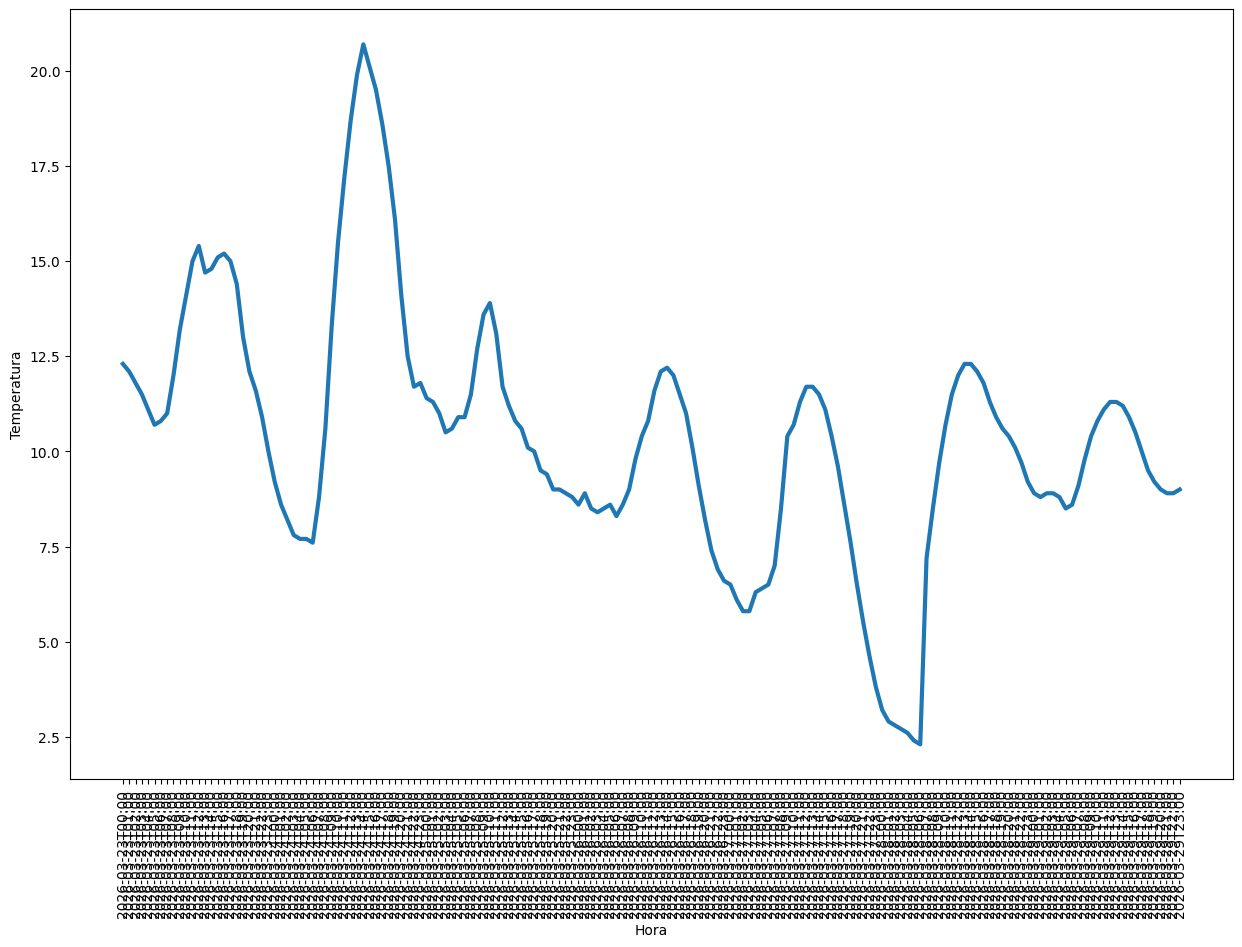

In [ ]:
plt.figure(figsize=(15,10))
sns.lineplot(data=weatherdf,
             x="Hora",
             y="Temperatura",
            #  hue="country",
            linewidth = 3);

plt.xticks(rotation=90);

# No he conseguido meter bien los nombres del eje x para que se vean correctamente los valores